# Netflix Content Analysis — Exploratory Data Analysis

## Project Overview

This project explores Netflix's Movies and TV Shows catalog using Python.

The objective is to identify patterns and trends in:

- Content type
- Release and addition trends
- Countries contributing to the catalog
- Content ratings
- Genres
- Movie-to-TV Show ratio
- Monthly content additions
- Movie duration
- International content

The analysis uses Pandas, NumPy and Matplotlib to answer
business-oriented questions and generate insights from the dataset.

## Tools Used

- Python
- Pandas — data cleaning and analysis
- NumPy — numerical operations
- Matplotlib — visualization

## Dataset

Netflix Movies and TV Shows dataset.

The dataset contains information such as:

- Title
- Type
- Director
- Cast
- Country
- Date Added
- Release Year
- Rating
- Duration
- Genre
- Description

# IMPORTING LIBRARIES

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTING FILES

In [102]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [103]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 8807
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Initial Observations

The dataset contains 8,807 Netflix titles and 12 variables.

Most variables are categorical/text-based, while `release_year`
is numerical. Several columns contain missing values, which will
be handled before analysis.

In [104]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

director      2634
country        831
cast           825
date_added      10
rating           4
duration         3
dtype: int64


# 2. Data Cleaning

The following steps will be performed:

1. Remove duplicate records.
2. Convert `date_added` to datetime.
3. Handle missing categorical values.
4. Convert appropriate columns to suitable data types.
5. Create additional variables required for analysis.

In [105]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df))

Duplicate rows: 0
Rows after removing duplicates: 8807


In [106]:
fill_unknown = ['director', 'cast', 'country', 'rating', 'duration']

df[fill_unknown] = df[fill_unknown].fillna('Unknown')

In [107]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['release_year'] = pd.to_numeric(
    df['release_year'],
    errors='coerce'
)

df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')

In [108]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   category      
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   category      
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: category(2), datetime64[ns](1), int64(1), object(8)
memory usage: 706.2+ KB
None

Missing values:
show_id          0
type             0
title            0
director         0
cast       

# 3. Feature Engineering

Additional columns will be created for:

- Year the title was added to Netflix
- Month the title was added
- Numeric movie duration
- Numeric TV show seasons
- International content classification

In [109]:
df['year_added'] = df['date_added'].dt.year
df['month_number'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()

In [110]:
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

movies['duration_min'] = (
    movies['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

tv_shows['seasons'] = (
    tv_shows['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# 4. Business Questions

The analysis will answer the following questions:

1. Does Netflix have more Movies or TV Shows?
2. Which countries contribute the most titles?
3. Which content ratings are most common?
4. Which genres occur most frequently?
5. How has the Movie-to-TV Show ratio changed over time?
6. Which months does Netflix add the most content?
7. How does average movie duration differ before and after 2020?
8. Has Netflix been moving toward more international content?

## Q1. Does Netflix have more Movies or TV Shows?

In [111]:
content_counts = df['type'].value_counts()

print(content_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


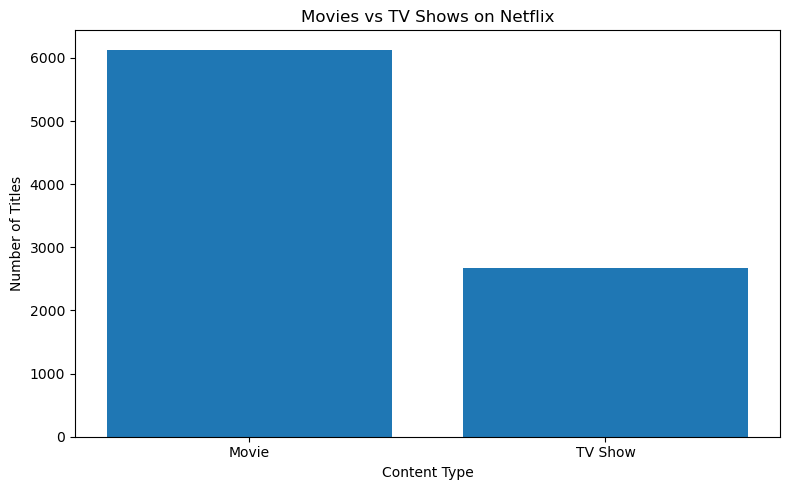

In [112]:
# visualization code

plt.figure(figsize=(8, 5))

plt.bar(
    content_counts.index,
    content_counts.values
)

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.show()

### Observation

The catalog contains more Movies than TV Shows.

### Interpretation

Netflix's catalog in this dataset is more heavily represented by
Movies than TV Shows.

## Q2. Which countries contribute the most titles?

In [113]:
country_data = (
    df[df['country'] != 'Unknown']['country']
    .str.split(',')
    .explode()
    .str.strip()
)

country_counts = country_data.value_counts()

country_counts.head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

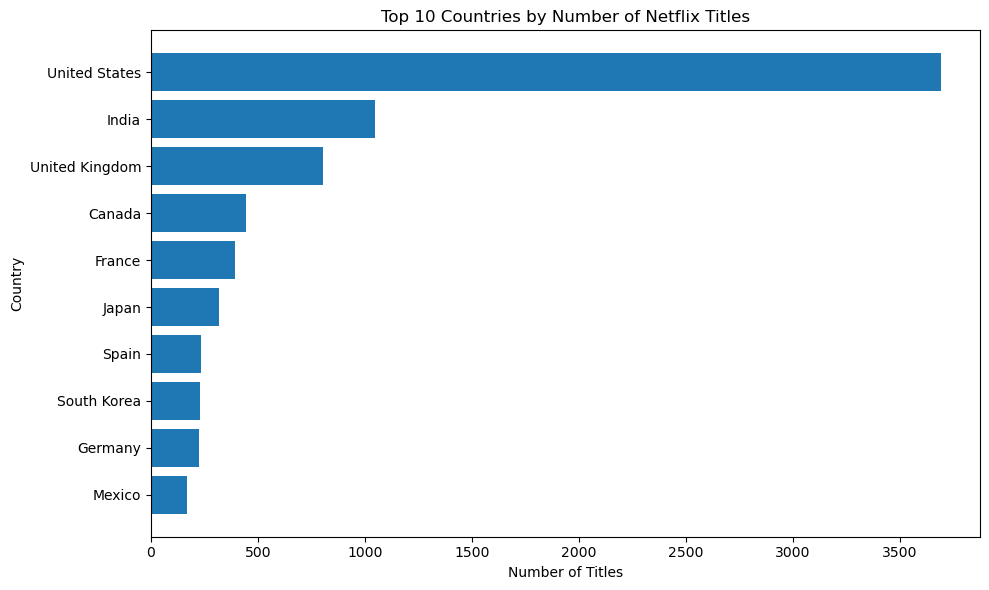

In [114]:
# visualization code

top_countries = country_counts.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

### Observation

The United States contributes the largest number of recorded titles,
followed by other major contributors such as India and the United Kingdom.

### Note

A title associated with multiple countries is counted once for each
country listed in the dataset.

## Q3. Which content ratings are most common on Netflix?

In [115]:
rating_counts = (
    df[df['rating'] != 'Unknown']['rating']
    .value_counts()
)

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
UR             3
NC-17          3
66 min         1
74 min         1
84 min         1
Unknown        0
Name: count, dtype: int64

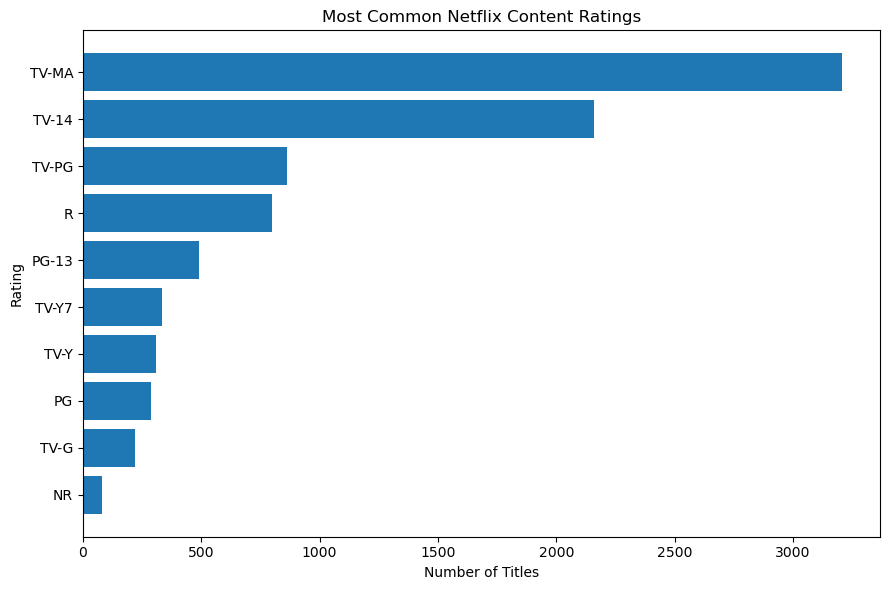

In [116]:
# visualization code

top_ratings = rating_counts.head(10).sort_values()

plt.figure(figsize=(9, 6))

plt.barh(
    top_ratings.index.astype(str),
    top_ratings.values
)

plt.title('Most Common Netflix Content Ratings')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

### Observation

The distribution of content ratings shows which audience categories
are most strongly represented in Netflix's catalog.

### Important distinction

A frequent rating indicates that the category is common in the catalog.
It does not necessarily mean that viewers prefer that rating.

## Q4. Which genres occur most frequently?

In [117]:
genre_data = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)

genre_counts = genre_data.value_counts()

genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

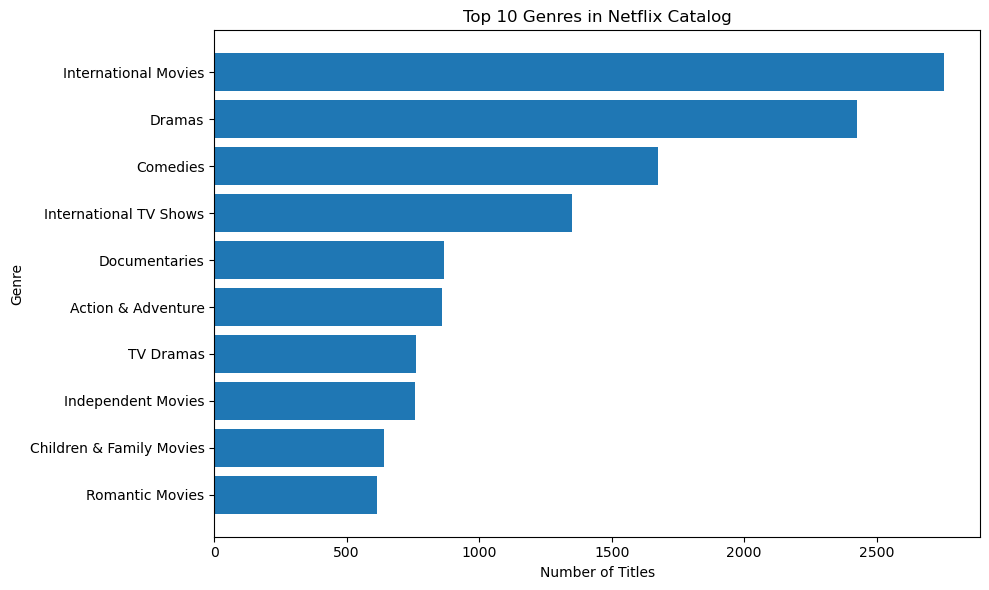

In [118]:
# visualization code

top_genres = genre_counts.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_genres.index,
    top_genres.values
)

plt.title('Top 10 Genres in Netflix Catalog')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

### Observation

The most frequently occurring genres represent the major content
categories in Netflix's catalog.

Because titles can belong to multiple genres, one title may contribute
to more than one genre count.

## Q5. How has the Movie-to-TV Show ratio changed over time?

In [119]:
yearly_type = pd.crosstab(
    df['release_year'],
    df['type']
)

yearly_type


type,Movie,TV Show
release_year,,
1925,0,1
1942,2,0
1943,3,0
1944,3,0
1945,3,1
...,...,...
2017,767,265
2018,767,380
2019,633,397


In [120]:
yearly_type['Movie_to_TV_Ratio'] = (
    yearly_type['Movie'] /
    yearly_type['TV Show']
)

ratio_data = (
    yearly_type['Movie_to_TV_Ratio']
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

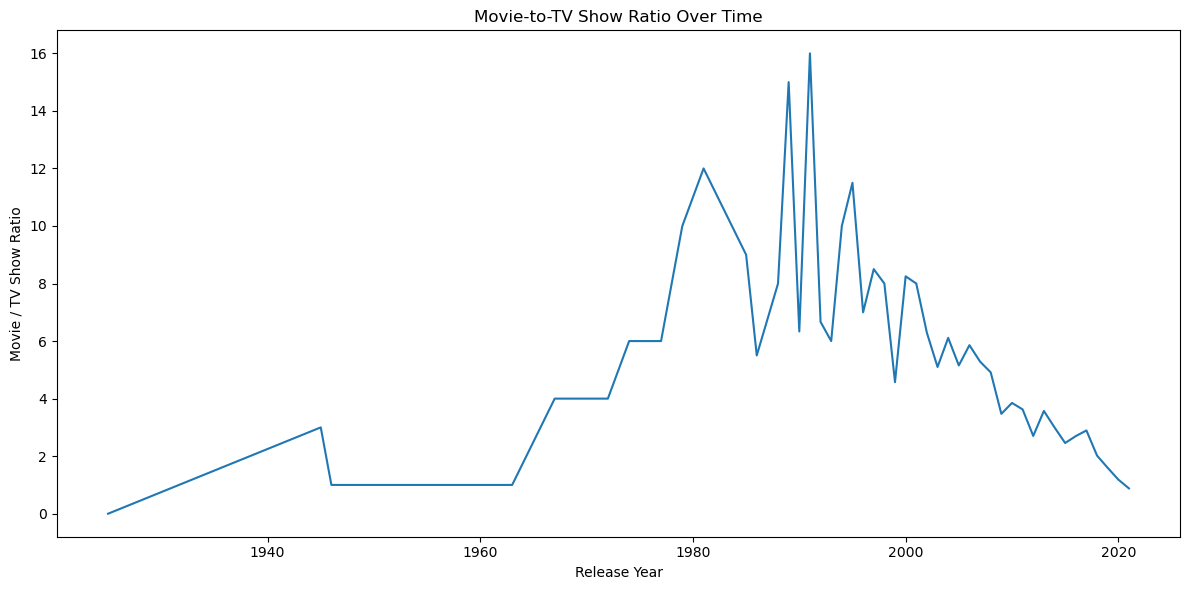

In [121]:
# visualization code

plt.figure(figsize=(12, 6))

plt.plot(
    ratio_data.index,
    ratio_data.values
)

plt.title('Movie-to-TV Show Ratio Over Time')
plt.xlabel('Release Year')
plt.ylabel('Movie / TV Show Ratio')

plt.tight_layout()
plt.show()

### Observation

The Movie-to-TV Show ratio changes across release years, indicating
that the composition of Netflix's catalog has not remained constant.

The trend should be interpreted together with the number of titles
available for each year.

## Q6. Which months does Netflix add the most content?

In [122]:
monthly_counts = (
    df.dropna(subset=['date_added'])
    .groupby('month_number')
    .size()
)

month_names = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_counts.index = [
    month_names[int(i) - 1]
    for i in monthly_counts.index
]

monthly_counts

January      727
February     557
March        734
April        759
May          626
June         724
July         819
August       749
September    765
October      755
November     697
December     797
dtype: int64

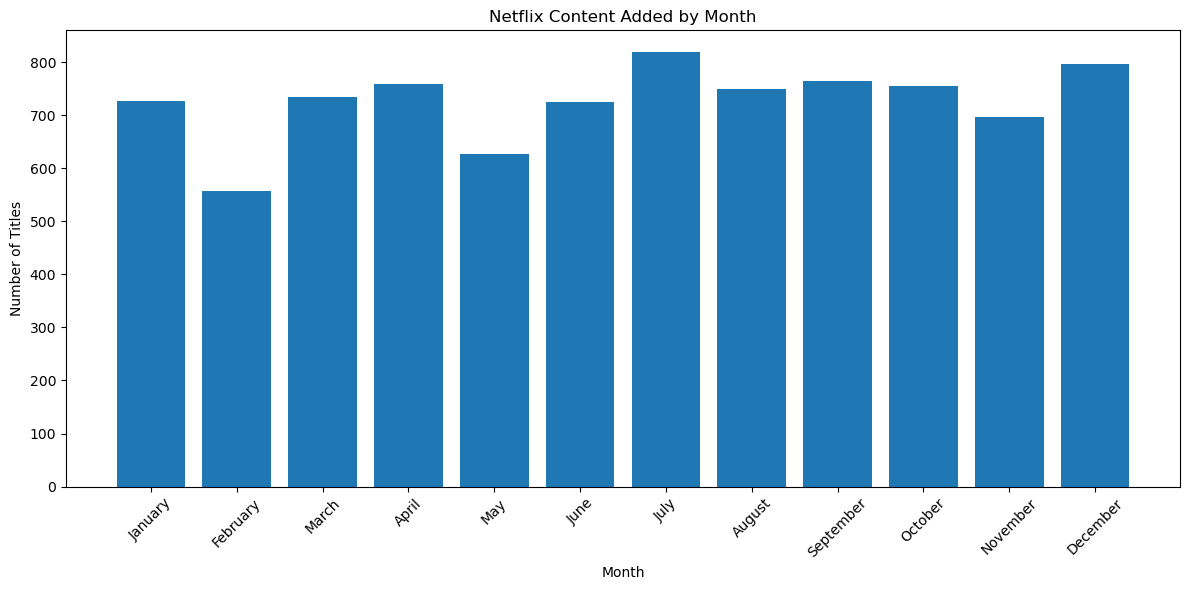

In [123]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_counts.index,
    monthly_counts.values
)

plt.title('Netflix Content Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Optional deeper analysis

We can also compare Movies and TV Shows within each month to determine
whether Netflix's monthly addition pattern differs by content type.

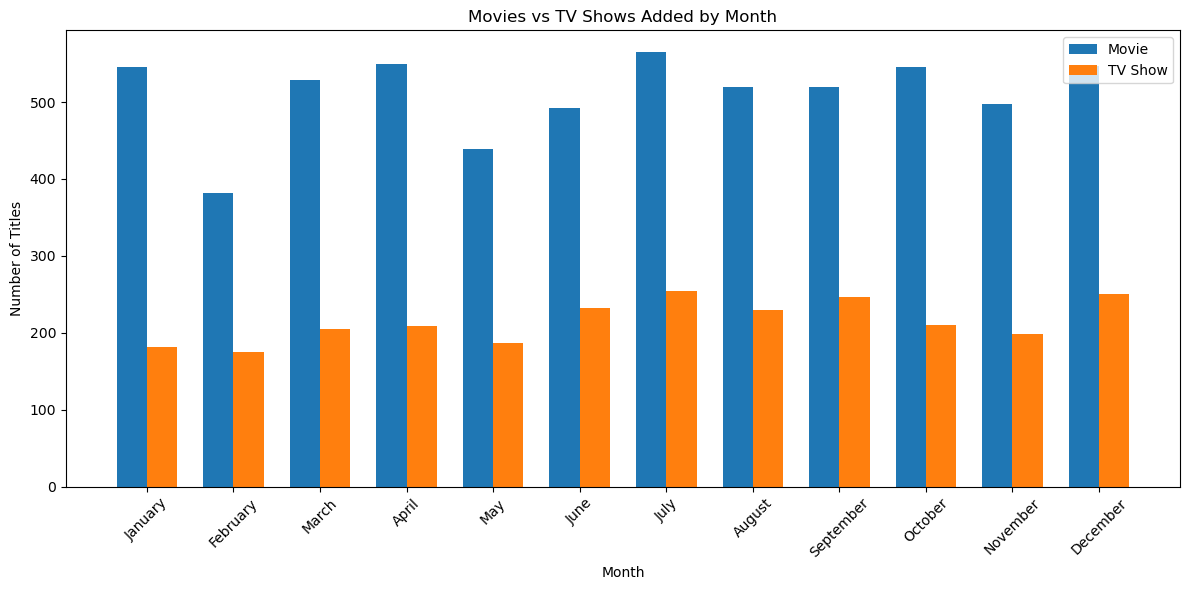

In [124]:
# ADDITIONAL VISUALIZATION

monthly_type = pd.crosstab(
    df['month_number'],
    df['type']
)

monthly_type = monthly_type.reindex(range(1, 13))

plt.figure(figsize=(12, 6))

x = np.arange(12)
width = 0.35

plt.bar(
    x - width / 2,
    monthly_type['Movie'],
    width,
    label='Movie'
)

plt.bar(
    x + width / 2,
    monthly_type['TV Show'],
    width,
    label='TV Show'
)

plt.title('Movies vs TV Shows Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')

plt.xticks(x, month_names, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Q7. How does average movie duration differ before and after 2020?

For this analysis, release year is used to separate movies into:

- Before 2020
- 2020 and after

This shows whether average movie duration differs between the two periods.

In [125]:
movies_duration = movies.dropna(
    subset=['duration_min', 'release_year']
).copy()

pre_2020 = movies_duration[
    movies_duration['release_year'] < 2020
]

post_2020 = movies_duration[
    movies_duration['release_year'] >= 2020
]

avg_pre = pre_2020['duration_min'].mean()
avg_post = post_2020['duration_min'].mean()

print(f"Average movie duration before 2020: {avg_pre:.2f} minutes")
print(f"Average movie duration from 2020 onward: {avg_post:.2f} minutes")

Average movie duration before 2020: 100.46 minutes
Average movie duration from 2020 onward: 93.64 minutes


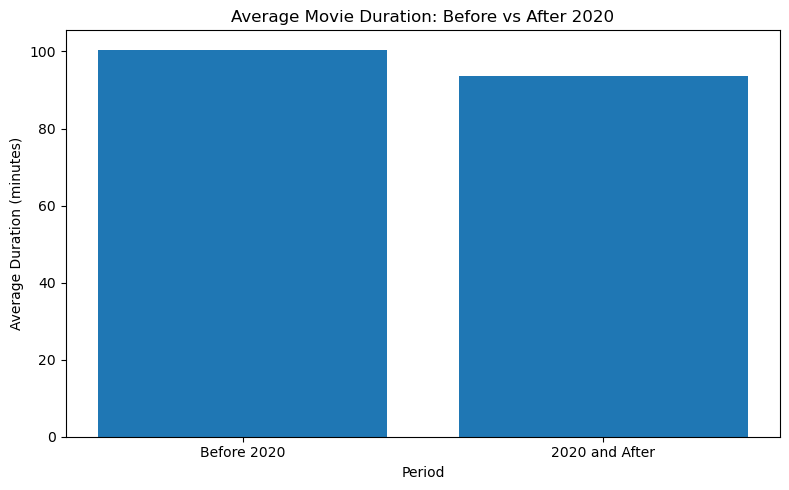

In [126]:
# visualization code

duration_comparison = pd.Series({
    'Before 2020': avg_pre,
    '2020 and After': avg_post
})

plt.figure(figsize=(8, 5))

plt.bar(
    duration_comparison.index,
    duration_comparison.values
)

plt.title('Average Movie Duration: Before vs After 2020')
plt.xlabel('Period')
plt.ylabel('Average Duration (minutes)')

plt.tight_layout()
plt.show()

### Observation

The average movie duration differs between the two periods.

This analysis identifies a difference in the dataset but does not establish
that the COVID-19 pandemic caused the change.

## Q8. Has Netflix been moving toward more international content over time?

### Definition

For this analysis, a title is considered to have international
production involvement if its recorded country information contains
at least one country other than the United States.

Titles with multiple countries are therefore included when at least
one of those countries is outside the United States.

In [127]:
international_df = df[
    (df['country'] != 'Unknown') &
    (df['year_added'].notna())
].copy()

international_df['country_list'] = (
    international_df['country']
    .str.split(',')
    .apply(
        lambda countries: [
            country.strip()
            for country in countries
        ]
    )
)

international_df['is_international'] = (
    international_df['country_list']
    .apply(
        lambda countries:
        any(country != 'United States' for country in countries)
    )
)

In [128]:
yearly_total = (
    international_df
    .groupby('year_added')
    .size()
)

yearly_international = (
    international_df[
        international_df['is_international']
    ]
    .groupby('year_added')
    .size()
)

international_percentage = (
    yearly_international
    .div(yearly_total)
    .mul(100)
)

international_percentage

year_added
2008.0          NaN
2009.0    50.000000
2010.0          NaN
2011.0    15.384615
2012.0    33.333333
2013.0    30.000000
2014.0    34.782609
2015.0    37.142857
2016.0    61.904762
2017.0    67.788899
2018.0    70.603849
2019.0    63.429192
2020.0    64.745763
2021.0    60.701754
dtype: float64

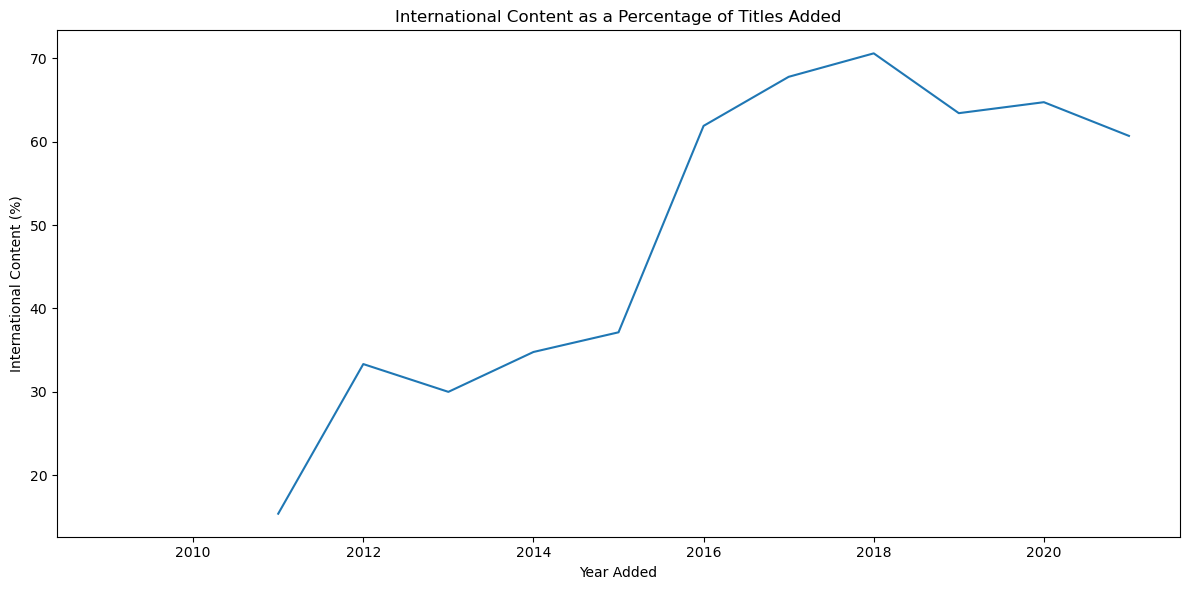

In [129]:
plt.figure(figsize=(12, 6))

plt.plot(
    international_percentage.index,
    international_percentage.values
)

plt.title('International Content as a Percentage of Titles Added')
plt.xlabel('Year Added')
plt.ylabel('International Content (%)')

plt.tight_layout()
plt.show()

### Observation

The trend shows how the share of titles with international production
involvement changes over time.

This analysis should be interpreted as a catalog trend rather than
evidence of Netflix's overall business strategy, because the dataset
does not contain Netflix's complete investment or production data.

## Q9. How has the number of titles added to Netflix changed over time?

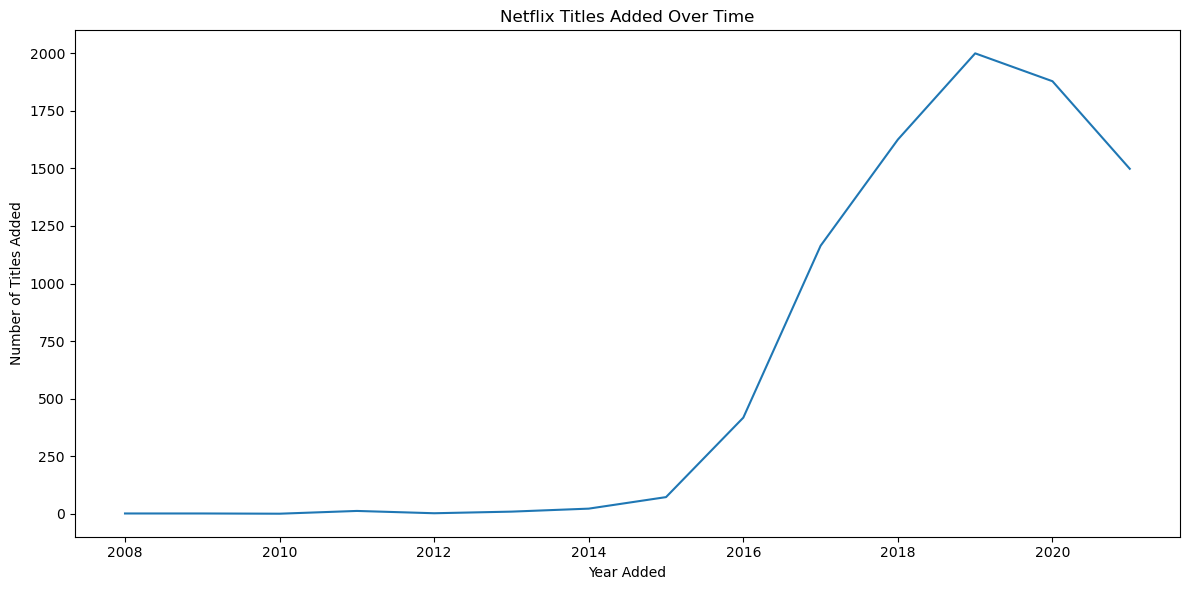

In [130]:
yearly_additions = (
    df.dropna(subset=['date_added'])
    .groupby('year_added')
    .size()
)

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_additions.index,
    yearly_additions.values
)

plt.title('Netflix Titles Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')

plt.tight_layout()
plt.show()

## Q10. How has the composition of Netflix additions changed over time?

In [131]:
yearly_type_added = pd.crosstab(
    df['year_added'],
    df['type']
)

yearly_type_added = yearly_type_added.dropna()

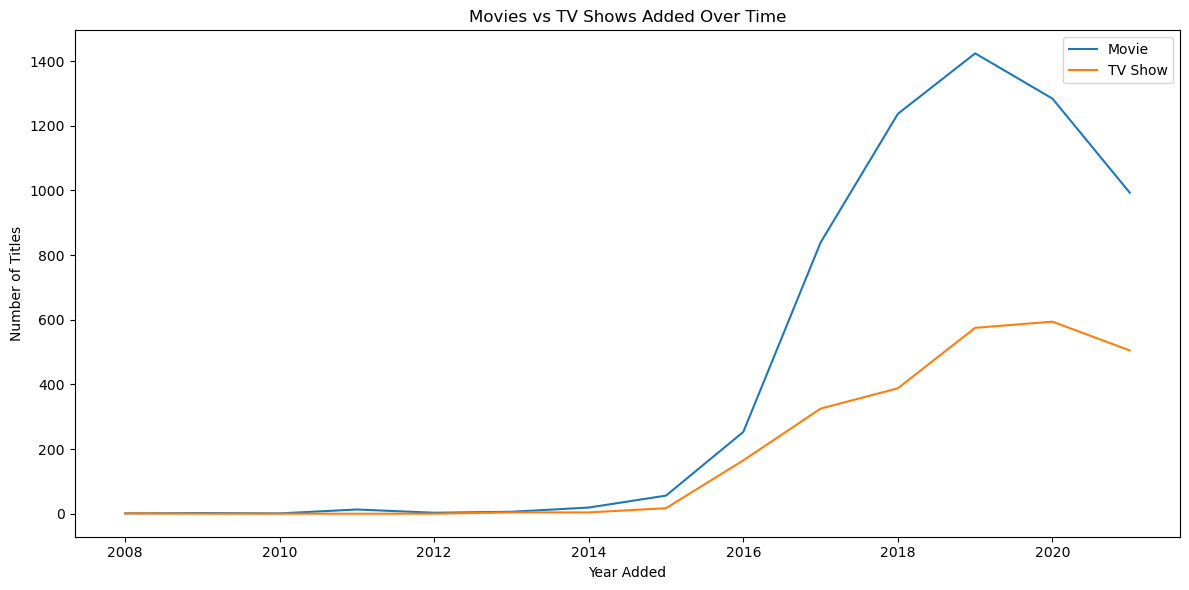

In [132]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_type_added.index,
    yearly_type_added['Movie'],
    label='Movie'
)

plt.plot(
    yearly_type_added.index,
    yearly_type_added['TV Show'],
    label='TV Show'
)

plt.title('Movies vs TV Shows Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.legend()

plt.tight_layout()
plt.show()

# Key Findings

Based on the analysis, summarize the most important findings.

### Content Mix
- Which content type dominates the catalog?
- How does the content mix change over time?

### Geography
- Which countries contribute the most titles?
- Is international production involvement increasing?

### Content Categories
- Which ratings are most common?
- Which genres occur most frequently?

### Time Trends
- Which years saw the most additions?
- Which months saw the most additions?
- How has the Movie-to-TV Show ratio changed?

### Duration
- What is the average movie duration?
- How does duration differ before and after 2020?

#  Limitations

1. The `country` column can contain multiple countries in a single row,
   so country counts depend on how multi-country titles are handled.

2. Several columns contain missing values, particularly director,
   cast and country.

3. The dataset describes Netflix's catalog rather than viewer behavior.

4. A genre appearing frequently does not necessarily mean that viewers
   prefer that genre.

5. The dataset does not contain viewing hours, revenue, subscriber
   engagement or other performance metrics.

6. Therefore, the analysis identifies patterns in Netflix's catalog but
   cannot directly measure content popularity or financial performance.

# 7. Conclusion

This exploratory analysis examined Netflix's content catalog across
content type, geography, ratings, genres, duration and time.

The analysis demonstrates how data cleaning, feature engineering,
aggregation and visualization can be used to answer business-oriented
questions from a real-world dataset.

The results provide descriptive insights into Netflix's catalog, while
the limitations highlight areas where additional data would be required
to evaluate viewer behavior or business performance.